In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

import os
import sys

parent_dir = os.path.abspath("..")
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from utils.load_data import load_processed_original_data  # noqa: E402
from utils.constants import FIGURES_DIR  # noqa: E402
from utils.configure_scienceplots import configure_scienceplots  # noqa: E402

FIGSIZE = (8, 4)

HISTPLOT_FIGURES_DIR = FIGURES_DIR / "histplots"
HISTPLOT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

HEATMAP_FIGURES_DIR = FIGURES_DIR / "heatmaps"
HEATMAP_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
configure_scienceplots()

In [3]:
df = load_processed_original_data(parse_dates=True)
df.head()

,OBJECTID,FORMULARIO,CODIGO_ACCIDENTE,FECHA_OCURRENCIA,DIA_SEMANA_OCURRENCIA,GRAVEDAD,CLASE,LOCALIDAD,latitude,longitude
0,646545,A00410124,306211,2008-09-05 12:50:00,5,CON HERIDOS,ATROPELLO,TEUSAQUILLO,4.655402,-74.101700
1,563782,839933000,291565,2008-05-20 23:40:00,2,SOLO DANOS,CHOQUE,ENGATIVA,4.689417,-74.109351
2,4398952,A000038718,4398952,2014-12-04 17:30:00,4,SOLO DANOS,CHOQUE,ENGATIVA,4.689750,-74.109016
3,1612,726750500,30243,2007-06-29 19:30:00,5,CON HERIDOS,ATROPELLO,PUENTE ARANDA,4.615129,-74.108947
4,569692,840564600,297475,2008-07-21 07:30:00,1,SOLO DANOS,CHOQUE,TEUSAQUILLO,4.646696,-74.108792


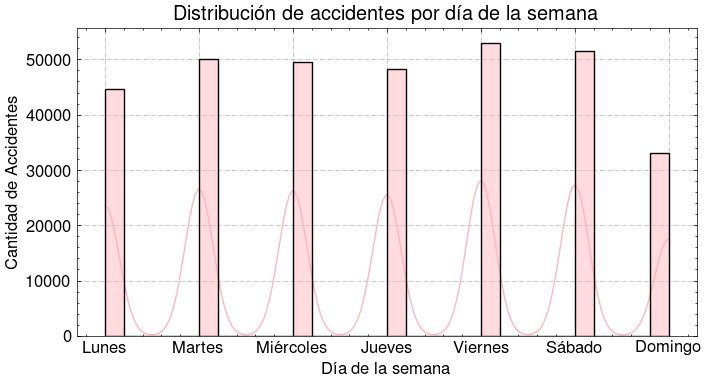

In [5]:
fig, ax = plt.subplots(figsize=FIGSIZE)

sns.histplot(
    df,
    x="DIA_SEMANA_OCURRENCIA",
    bins=30,
    zorder=10,
    color="lightpink",
    kde=True,
    ax=ax,
)

ax.set(
    title="Distribución de accidentes por día de la semana",
    xlabel="Día de la semana",
    ylabel="Cantidad de Accidentes",
)

dias = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]
ax.set_xticks(ticks=range(1, len(dias) + 1), labels=dias)

ax.grid(linestyle="-.")
fig.savefig(HISTPLOT_FIGURES_DIR / "accidents_per_day_of_week.pdf")
plt.show()

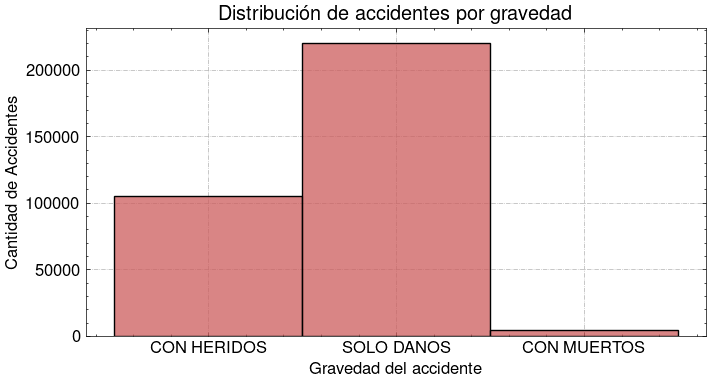

In [ ]:
fig, ax = plt.subplots(figsize=FIGSIZE)

sns.histplot(df, x="GRAVEDAD", zorder=20, color="indianred", ax=ax)

ax.set(
    title="Distribución de accidentes por gravedad",
    xlabel="Gravedad del accidente",
    ylabel="Cantidad de Accidentes",
)

ax.grid(linestyle="-.")
fig.savefig(HISTPLOT_FIGURES_DIR / "accidents_per_gravity.pdf")
plt.show()

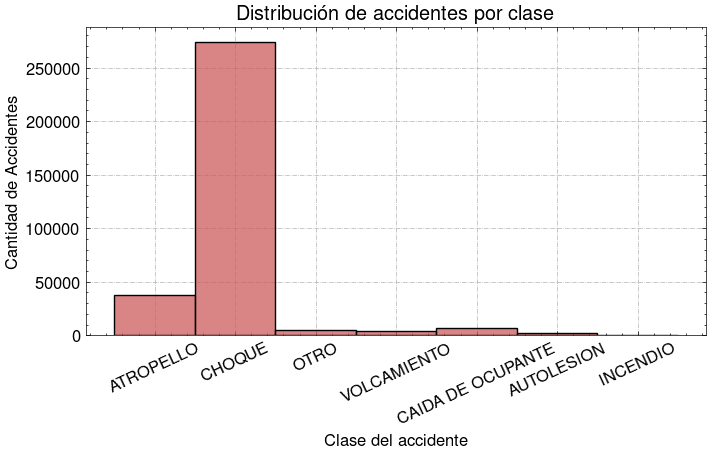

In [55]:
fig, ax = plt.subplots(figsize=FIGSIZE)

sns.histplot(df, x="CLASE", zorder=20, color="indianred", ax=ax)

ax.set(
    title="Distribución de accidentes por clase",
    xlabel="Clase del accidente",
    ylabel="Cantidad de Accidentes",
)
plt.xticks(rotation=25, ha="center")

plt.grid(linestyle="-.")
plt.savefig(HISTPLOT_FIGURES_DIR / "accidents_per_class.pdf")
plt.show()

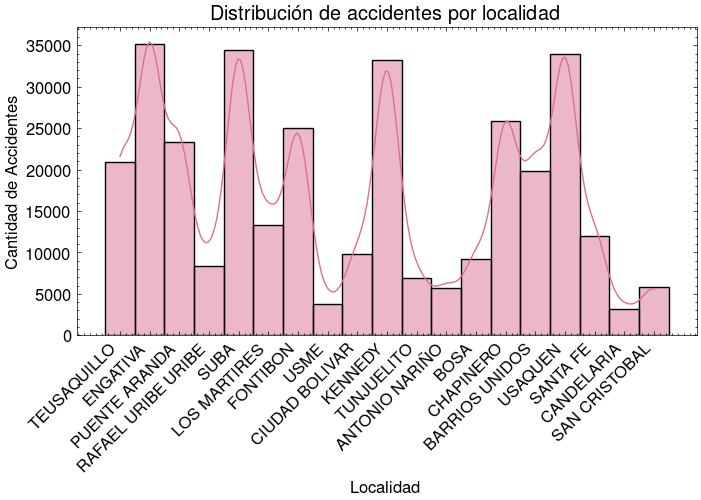

In [ ]:
fig, ax = plt.subplots(figsize=FIGSIZE)

sns.histplot(df, x="LOCALIDAD", color="palevioletred", kde=True)

ax.set(
    title="Distribución de accidentes por localidad",
    xlabel="Localidad",
    ylabel="Cantidad de Accidentes",
)
plt.xticks(rotation=45, ha="right")

plt.savefig(HISTPLOT_FIGURES_DIR / "accidents_per_locality.pdf")
plt.show()

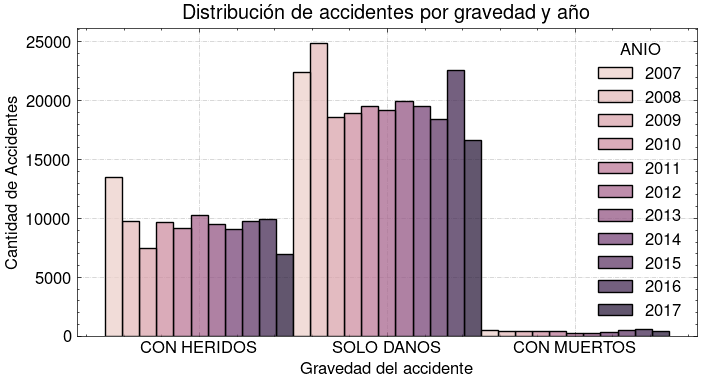

In [61]:
# Cómo varía la gravedad de los accidentes por año
df["ANIO"] = df["FECHA_OCURRENCIA"].dt.year

fig, ax = plt.subplots(figsize=FIGSIZE)

sns.histplot(data=df, x="GRAVEDAD", hue="ANIO", multiple="dodge", zorder=10, ax=ax)

ax.set(
    title="Distribución de accidentes por gravedad y año",
    xlabel="Gravedad del accidente",
    ylabel="Cantidad de Accidentes",
)

ax.grid(linestyle="-.", alpha=0.7)

plt.savefig(HISTPLOT_FIGURES_DIR / "accidents_per_year_and_gravity.pdf")
plt.show()


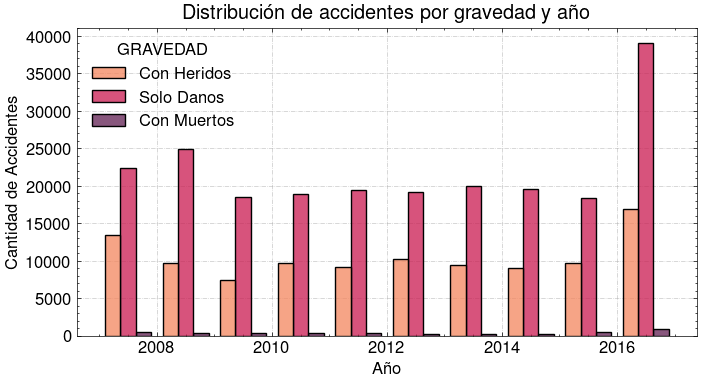

In [ ]:
# Evolución de los accidentes por gravedad a lo largo del tiempo.
df["ANIO"] = df["FECHA_OCURRENCIA"].dt.year

fig, ax = plt.subplots(figsize=FIGSIZE)

sns.histplot(
    data=df.replace(
        {gravity: gravity.strip().title() for gravity in df["GRAVEDAD"].unique()}
    ),
    x="ANIO",
    hue="GRAVEDAD",
    multiple="dodge",
    palette="rocket_r",
    shrink=0.8,
    binwidth=1,
    ax=ax,
    zorder=10,
)

ax.set(
    title="Distribución de accidentes por gravedad y año",
    xlabel="Año",
    ylabel="Cantidad de Accidentes",
)

# plt.legend(title="Gravedad", labels=["Solo daños", "Con heridos", "Con muertos"])
ax.grid(linestyle="-.", alpha=0.7)
plt.savefig(HISTPLOT_FIGURES_DIR / "accidents_per_gravity_and_year.pdf")
plt.show()

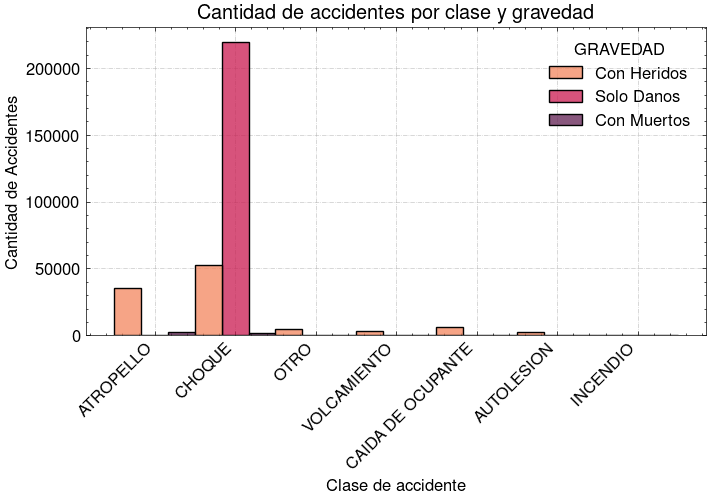

In [73]:
fig, ax = plt.subplots(figsize=FIGSIZE)

sns.histplot(
    data=df.replace(
        {gravity: gravity.strip().title() for gravity in df["GRAVEDAD"].unique()}
    ),
    x="CLASE",
    hue="GRAVEDAD",
    multiple="dodge",
    palette="rocket_r",
    ax=ax,
    zorder=10,
)

ax.set(
    title="Cantidad de accidentes por clase y gravedad",
    xlabel="Clase de accidente",
    ylabel="Cantidad de Accidentes",
)

plt.xticks(ticks=range(7), rotation=45, ha="right")
ax.grid(linestyle="-.", alpha=0.7)

fig.savefig(HISTPLOT_FIGURES_DIR / "accidents_per_class_and_gravity.pdf")
plt.show()

/tmp/ipykernel_109210/1406615413.py:25: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


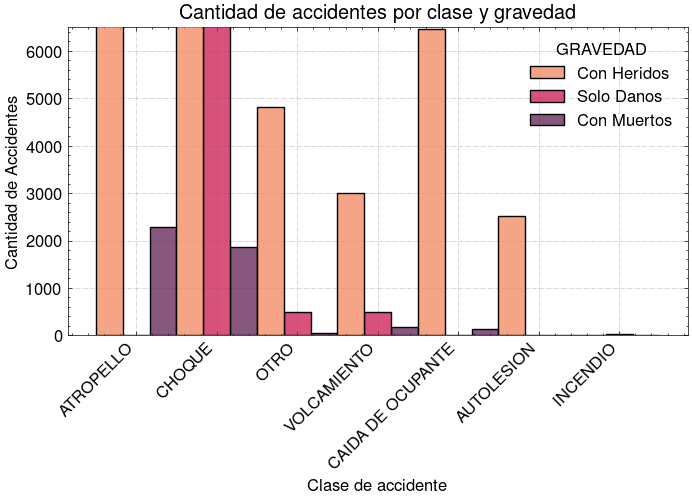

In [79]:
fig, ax = plt.subplots(figsize=FIGSIZE)

sns.histplot(
    data=df.replace(
        {gravity: gravity.strip().title() for gravity in df["GRAVEDAD"].unique()}
    ),
    x="CLASE",
    hue="GRAVEDAD",
    multiple="dodge",
    palette="rocket_r",
    ax=ax,
    zorder=10,
)

ax.set(
    title="Cantidad de accidentes por clase y gravedad",
    xlabel="Clase de accidente",
    ylabel="Cantidad de Accidentes",
)

plt.xticks(ticks=range(7), rotation=45, ha="right")
ax.grid(linestyle="-.", alpha=0.7)

ax.set_ylim(0, 6500)
fig.show()